## __Phase 2: Data Preparation__

### __Import packages__

In [1]:
import pandas as pd
import numpy as np
from haversine import haversine
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from scripts.data_pipeline.data_preprocessing.AIS.step01_filter_short_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step02_filter_speed_outliers import * 
from scripts.data_pipeline.data_preprocessing.AIS.step03_make_continuous_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step04_create_sample_data import * 
from scripts.visualization.map_vessel_routes_v2 import * 
from scripts.data_pipeline.data_matching.create_training_data import * 

### __Load 'cargo' data__

In [3]:
df_preprocessing = (
    pd.read_parquet("../data/processed/cargo_vessels.parquet")[["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]]
    .sort_values(["MMSI", "BaseDateTime"])
    .reset_index(drop=True)
    .copy()
)
df_preprocessing.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
0,8,None,2024-01-31 16:57:25,47.55391,-122.65412,0.0,511.0
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0


### __Step 1: Filter out trajectories that contain less than 5 data points__

In [4]:
df_prep_step1 = remove_short_tracks(df_preprocessing, min_observations=5)
df_prep_step1.head(5)

80 tracks with ≤ 5 observations were removed


,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0
5,205717000,IMO9748485,2024-01-01 03:23:14,46.89343,-125.51669,13.7,93.0


### __Step 2: Filtering unrealistic vessel speeds__

AIS data was filtered to exclude extreme and unlikely speeds. This includes removing vessels that were either nearly stationary or moving at technically implausible speeds.


In [5]:
df_prep_step2 = df_prep_step1.copy()
df_speed = add_speed_info(df_prep_step2)
df_speed

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,prev_lat,prev_lon,distance_diff,speed_kph
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0,NaN,NaN,NaN,NaN,0.000000
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0,1618.0,46.89866,-125.72790,10.296077,22.908453
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0,71.0,46.89496,-125.59250,0.490005,24.845311
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0,610.0,46.89473,-125.58606,4.288228,25.307573
5,205717000,IMO9748485,2024-01-01 03:23:14,46.89343,-125.51669,13.7,93.0,140.0,46.89337,-125.52966,0.985561,25.343009
...,...,...,...,...,...,...,...,...,...,...,...,...
14681508,750000076,IMO7053264,2024-01-05 03:58:10,16.36608,-65.55114,7.0,144.0,160.0,16.36872,-65.55590,0.586579,13.198027
14681509,750000076,IMO7053264,2024-01-05 04:04:39,16.35969,-65.53966,7.0,144.0,389.0,16.36608,-65.55114,1.415993,13.104308
14681510,750000076,IMO7053264,2024-01-05 04:07:50,16.35669,-65.53414,6.9,145.0,191.0,16.35969,-65.53966,0.676861,12.757598
14681511,750000076,IMO7053264,2024-01-05 11:41:39,15.92994,-64.71037,7.2,137.0,27229.0,16.35669,-65.53414,99.967283,13.216872


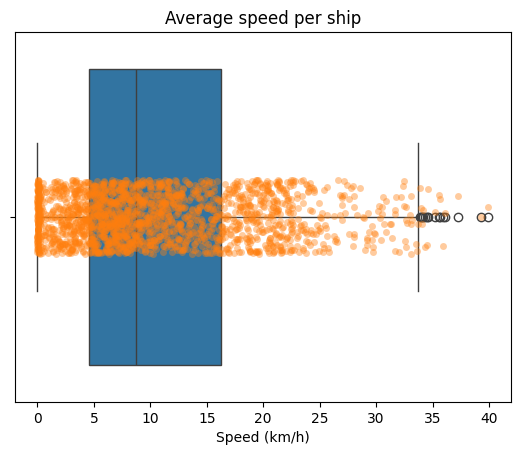

In [6]:
# Remove high-speed outliers (unrealistically fast vessels, as observed during data exploration (phase 1))
# df_prep_step2 = df_prep_step1.copy()
# df_speed = add_speed_info(df_prep_step2)

df_prep_step2 = remove_high_speed_outliers(df_speed)
avg_speeds_boxplot_1 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_1, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_1, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

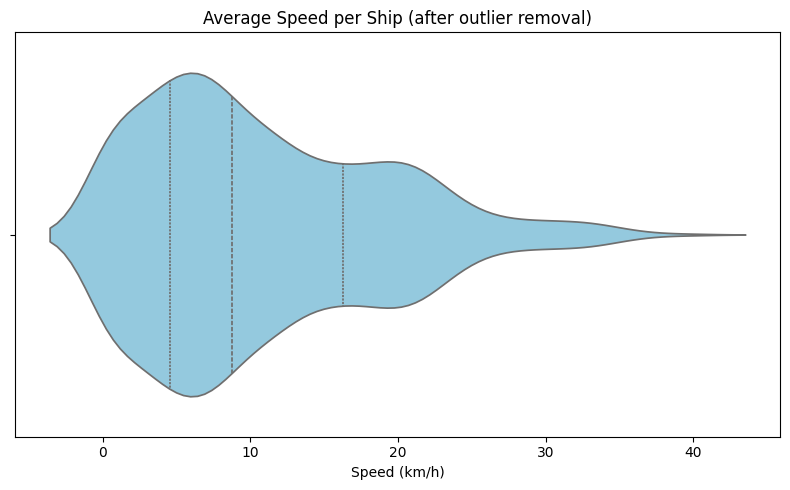

In [7]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=avg_speeds_boxplot_1, x="speed_kph", inner="quartile", color='skyblue')

plt.title("Average Speed per Ship (after outlier removal)")
plt.xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

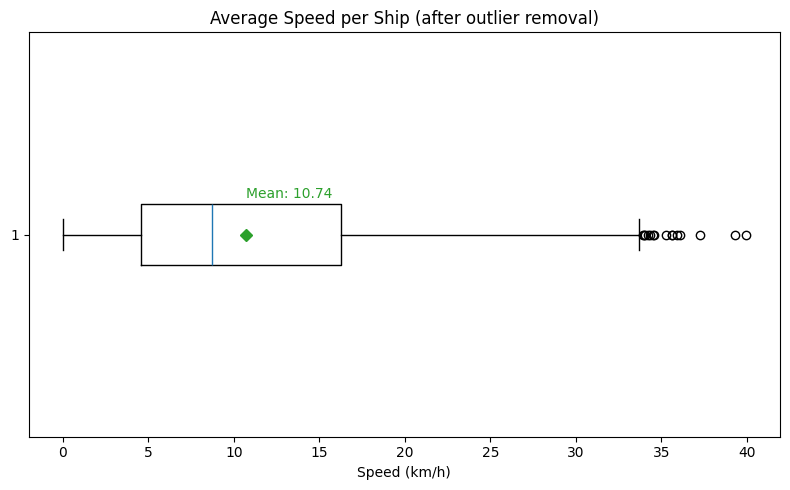

In [8]:
data = avg_speeds_boxplot_1["speed_kph"]
mean_speed = data.mean()

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data,
    vert=False,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='tab:green', markeredgecolor='tab:green')
)

for median in box['medians']:
    median.set_color('tab:blue')

ax.text(mean_speed, 1.1, f"Mean: {mean_speed:.2f}", color='tab:green', ha='left', va='center')

ax.set_title("Average Speed per Ship (after outlier removal)")
ax.set_xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

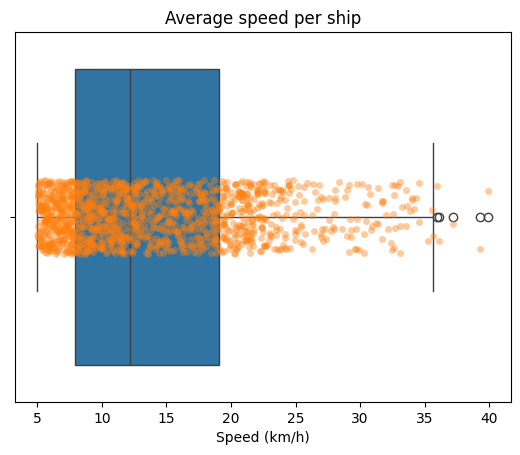

In [9]:
# Remove tracks with average speed below threshold (defaults is set to 5 km/h)
df_prep_step2 = remove_low_speed_outliers(df_prep_step2)
avg_speeds_boxplot_2 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_2, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_2, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

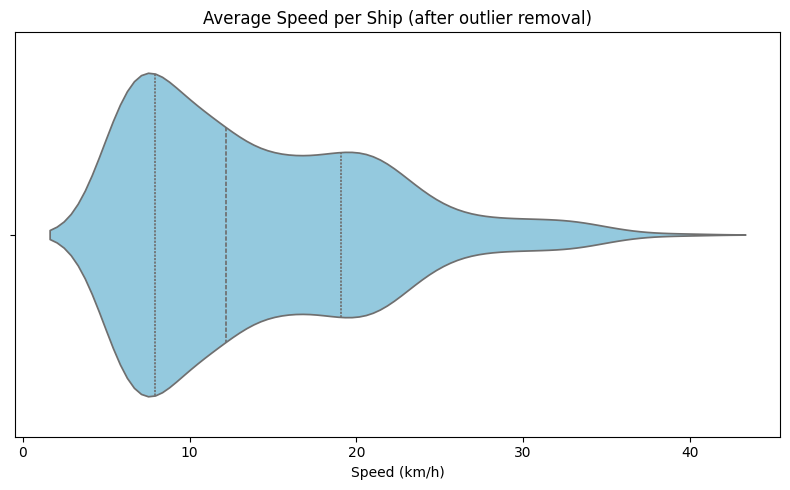

In [10]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=avg_speeds_boxplot_2, x="speed_kph", inner="quartile", color='skyblue')

plt.title("Average Speed per Ship (after outlier removal)")
plt.xlabel("Speed (km/h)")
plt.tight_layout()
plt.show()

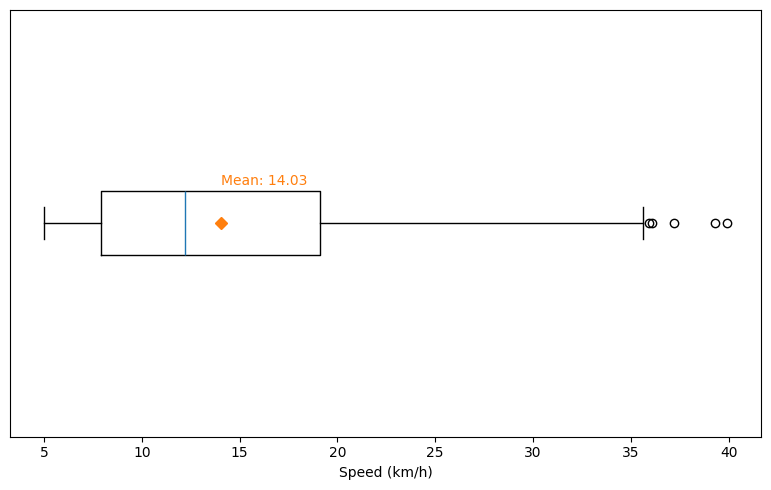

In [39]:
data = avg_speeds_boxplot_2["speed_kph"]
mean_speed = data.mean()

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    data,
    vert=False,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
)

for median in box['medians']:
    median.set_color('tab:blue')

ax.text(mean_speed, 1.1, f"Mean: {mean_speed:.2f}", color='tab:orange', ha='left', va='center')

# ax.set_title("Average Speed per Ship (after outlier removal)")
ax.set_xlabel("Speed (km/h)")
plt.tight_layout()
ax.set_yticks([])
plt.show()

### __Step 3: Handeling incomplete vessel tracks__

Some ships transmitted AIS signals only intermittently, leading to large time gaps between observations. A new trajectory (subroute) was initiated whenever the time gap exceeded the 99th percentile (~6 minutes)

In [12]:
df_prep_step3 = df_prep_step2.copy()
df_prep_step3 = split_into_continuous_tracks(df_prep_step3)
df_prep_step3.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [13]:
# 'Normal' track
plot_AIS_route(df_preprocessing, 636021579)

In [14]:
# Track splitted into more continuous trajectories
plot_AIS_subroutes(df_prep_step3, 636021579)

### __Step 4: Sampling a representative set of routes from the AIS population__

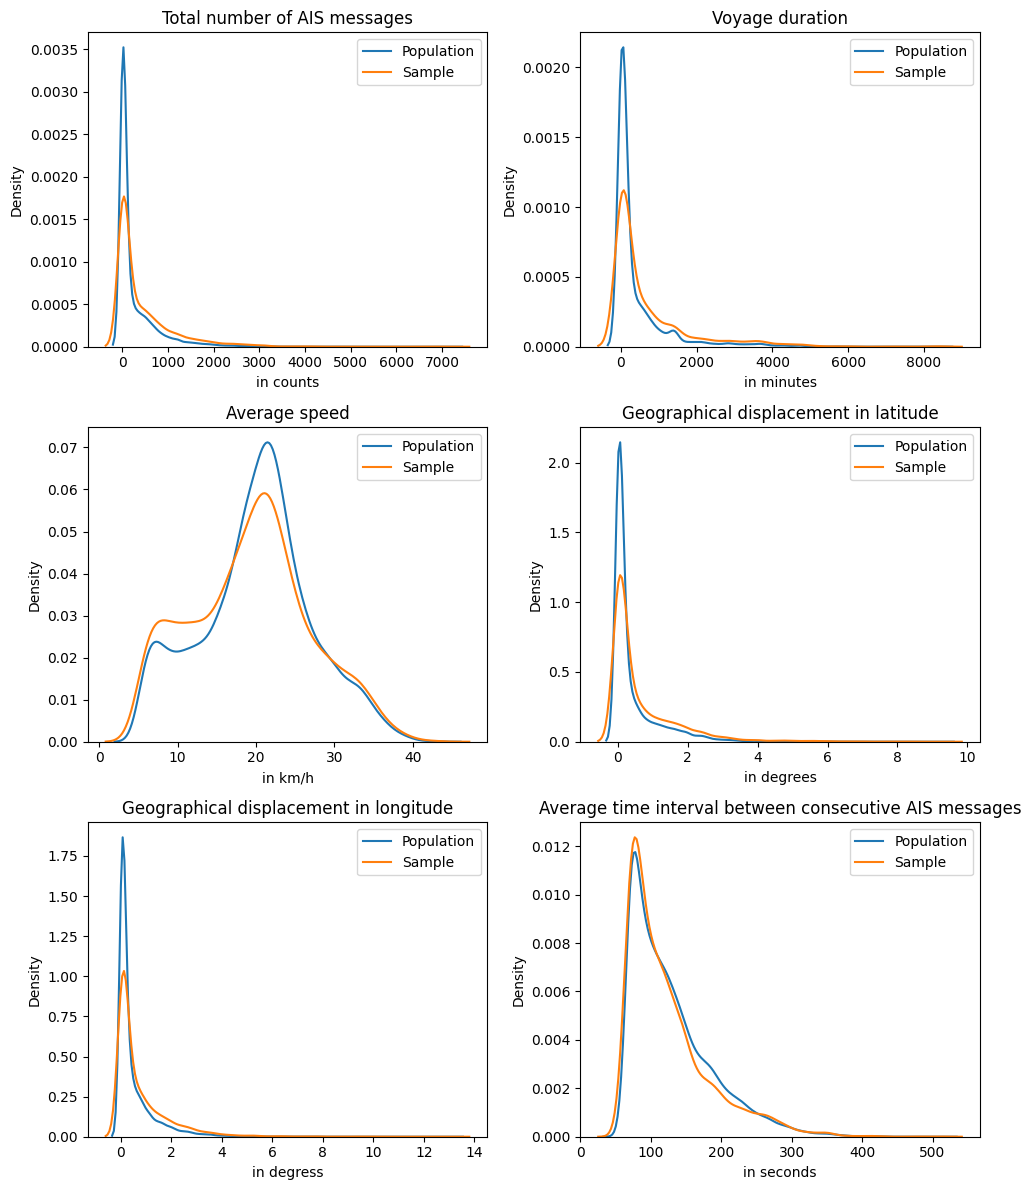

In [48]:
# Data
# sampled_tracks, AIS_charateristics, columns, df_subset = sample_representative_routes(df_prep_step3)

title_map = {
    "#points": "Total number of AIS messages",
    "track_duration": "Voyage duration",
    "avg_speed_kph": "Average speed",
    "lat_span": "Geographical displacement in latitude",
    "lon_span": "Geographical displacement in longitude",
    "mean_intra_time_diff": "Average time interval between consecutive AIS messages"
    }

xlabels = {
    "#points": "in counts",
    "track_duration": "in minutes",
    "avg_speed_kph": "in km/h",
    "lat_span": "in degrees",
    "lon_span": "in degress",
    "mean_intra_time_diff": "in seconds"
    }

# Subplot layout
n_cols = 2  # number of columns per row 
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  

# Plot columns
for idx, col in enumerate(columns):
    ax = axes[idx]
    sns.kdeplot(AIS_charateristics[col], label="Population", ax=ax)
    sns.kdeplot(sampled_tracks[col], label="Sample", color="tab:orange", ax=ax)
    
    title_name = title_map.get(col, col) 
    ax.set_title(title_name)
    axis_name = xlabels.get(col, col)
    ax.set_xlabel(axis_name)
    ax.legend()
    
plt.tight_layout()
plt.show()


In [27]:
sampled_tracks

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight
6225,"(354751000, 15)",359,729.383333,8.422928,0.13800,0.45217,122.243017,62.766426,0.154844,0.208307,0.625887,0.114460,0.787666,0.073953,-0.243298,0.097410,5.472008,3.927495
15930,"(636022462, 18)",420,522.983333,21.758160,1.07070,1.49433,74.890215,24.089990,0.453157,0.152429,0.674577,0.063200,0.820132,0.044274,-0.200176,0.065951,5.982846,4.462511
12139,"(538006167, 8)",1979,2885.350000,21.766905,4.21119,1.47923,87.523256,48.923027,0.437884,0.324976,0.651667,0.087826,0.804815,0.062766,-0.221287,0.100114,10.731568,14.627334
9855,"(378111467, 37)",7,19.483333,15.285804,0.00725,0.04047,194.833333,57.045304,0.828583,0.273608,0.487268,0.247994,0.681854,0.149476,-0.404544,0.202816,4.394124,2.999756
2583,"(266261000, 40)",1032,1430.883333,19.719140,2.34188,0.97944,83.271581,40.568604,0.365091,0.232925,0.670661,0.074051,0.817608,0.046674,-0.203087,0.059355,7.358261,6.293801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,"(304010766, 9)",8,30.433333,18.294282,0.05729,0.06365,260.857143,151.843591,1.328924,0.777603,0.419125,0.315532,0.604810,0.230932,-0.580362,0.400308,4.816718,3.334022
16045,"(636022893, 72)",282,334.900000,30.001334,1.49294,0.21673,71.508897,39.369687,0.596864,0.335970,0.661928,0.073476,0.811296,0.061051,-0.214284,0.119689,6.647083,5.268633
14289,"(577366000, 103)",186,258.350000,12.791165,0.12993,0.34185,83.789189,50.531349,0.250805,0.137301,0.695892,0.085279,0.832161,0.058307,-0.186887,0.085323,4.469045,3.056471
14471,"(636016243, 7)",9,16.683333,19.806503,0.02459,0.04403,125.125000,42.753237,0.689224,0.237470,0.584545,0.188821,0.756460,0.110967,-0.289376,0.141910,3.365191,2.319375


### __Create training data, inculding the generation of synthethic RF signals__

In [16]:
df_train_set, list_distance_diffs = generate_training_data(df_subset)

print("Max value:", max(list_distance_diffs))
df_train_set.head(5)

# Save files
df_train_set.to_pickle("../scripts/test_scripts/train_data_sample_5000_1.pkl") 
sampled_tracks.to_pickle("../scripts/test_scripts/statistics_sample_5000_1.pkl")  
df_subset.to_pickle("../scripts/test_scripts/AIS_sample_no_RF_5000_1.pkl")

Max value: 2.380675025323449


In [17]:
sampled_tracks

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight
6225,"(354751000, 15)",359,729.383333,8.422928,0.13800,0.45217,122.243017,62.766426,0.154844,0.208307,0.625887,0.114460,0.787666,0.073953,-0.243298,0.097410,5.472008,3.927495
15930,"(636022462, 18)",420,522.983333,21.758160,1.07070,1.49433,74.890215,24.089990,0.453157,0.152429,0.674577,0.063200,0.820132,0.044274,-0.200176,0.065951,5.982846,4.462511
12139,"(538006167, 8)",1979,2885.350000,21.766905,4.21119,1.47923,87.523256,48.923027,0.437884,0.324976,0.651667,0.087826,0.804815,0.062766,-0.221287,0.100114,10.731568,14.627334
9855,"(378111467, 37)",7,19.483333,15.285804,0.00725,0.04047,194.833333,57.045304,0.828583,0.273608,0.487268,0.247994,0.681854,0.149476,-0.404544,0.202816,4.394124,2.999756
2583,"(266261000, 40)",1032,1430.883333,19.719140,2.34188,0.97944,83.271581,40.568604,0.365091,0.232925,0.670661,0.074051,0.817608,0.046674,-0.203087,0.059355,7.358261,6.293801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,"(304010766, 9)",8,30.433333,18.294282,0.05729,0.06365,260.857143,151.843591,1.328924,0.777603,0.419125,0.315532,0.604810,0.230932,-0.580362,0.400308,4.816718,3.334022
16045,"(636022893, 72)",282,334.900000,30.001334,1.49294,0.21673,71.508897,39.369687,0.596864,0.335970,0.661928,0.073476,0.811296,0.061051,-0.214284,0.119689,6.647083,5.268633
14289,"(577366000, 103)",186,258.350000,12.791165,0.12993,0.34185,83.789189,50.531349,0.250805,0.137301,0.695892,0.085279,0.832161,0.058307,-0.186887,0.085323,4.469045,3.056471
14471,"(636016243, 7)",9,16.683333,19.806503,0.02459,0.04403,125.125000,42.753237,0.689224,0.237470,0.584545,0.188821,0.756460,0.110967,-0.289376,0.141910,3.365191,2.319375


### __Plot AIS data and RF signals__

In [49]:
df_train_set

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
2189886,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189888,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189879,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43139716169542, -66.44067859128745]",RF


In [51]:
plot_AIS_and_RF_data(df_subset, df_train_set, [(205717000, 3)])

In [23]:
df_train_set[(df_train_set["ID"] == (636021579, 0)) & (df_train_set["RF"].notna())]

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
2067621,"(636021579, 0)",0,636021579,2024-01-01 02:07:00,NaT,2024-01-01 02:07:00,None,"[32.003480864693984, -79.43295788008975]",RF
2067622,"(636021579, 0)",0,636021579,2024-01-01 05:08:47,NaT,2024-01-01 05:08:47,None,"[32.322338309281655, -78.78147559367189]",RF


In [19]:
df_train_set

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
2189886,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189888,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189879,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43139716169542, -66.44067859128745]",RF
